In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
from optiland.fileio import load_zemax_file

In [8]:
# Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

Loading lens models...
Generating spherical lens plot...


<Figure size 3000x1200 with 0 Axes>

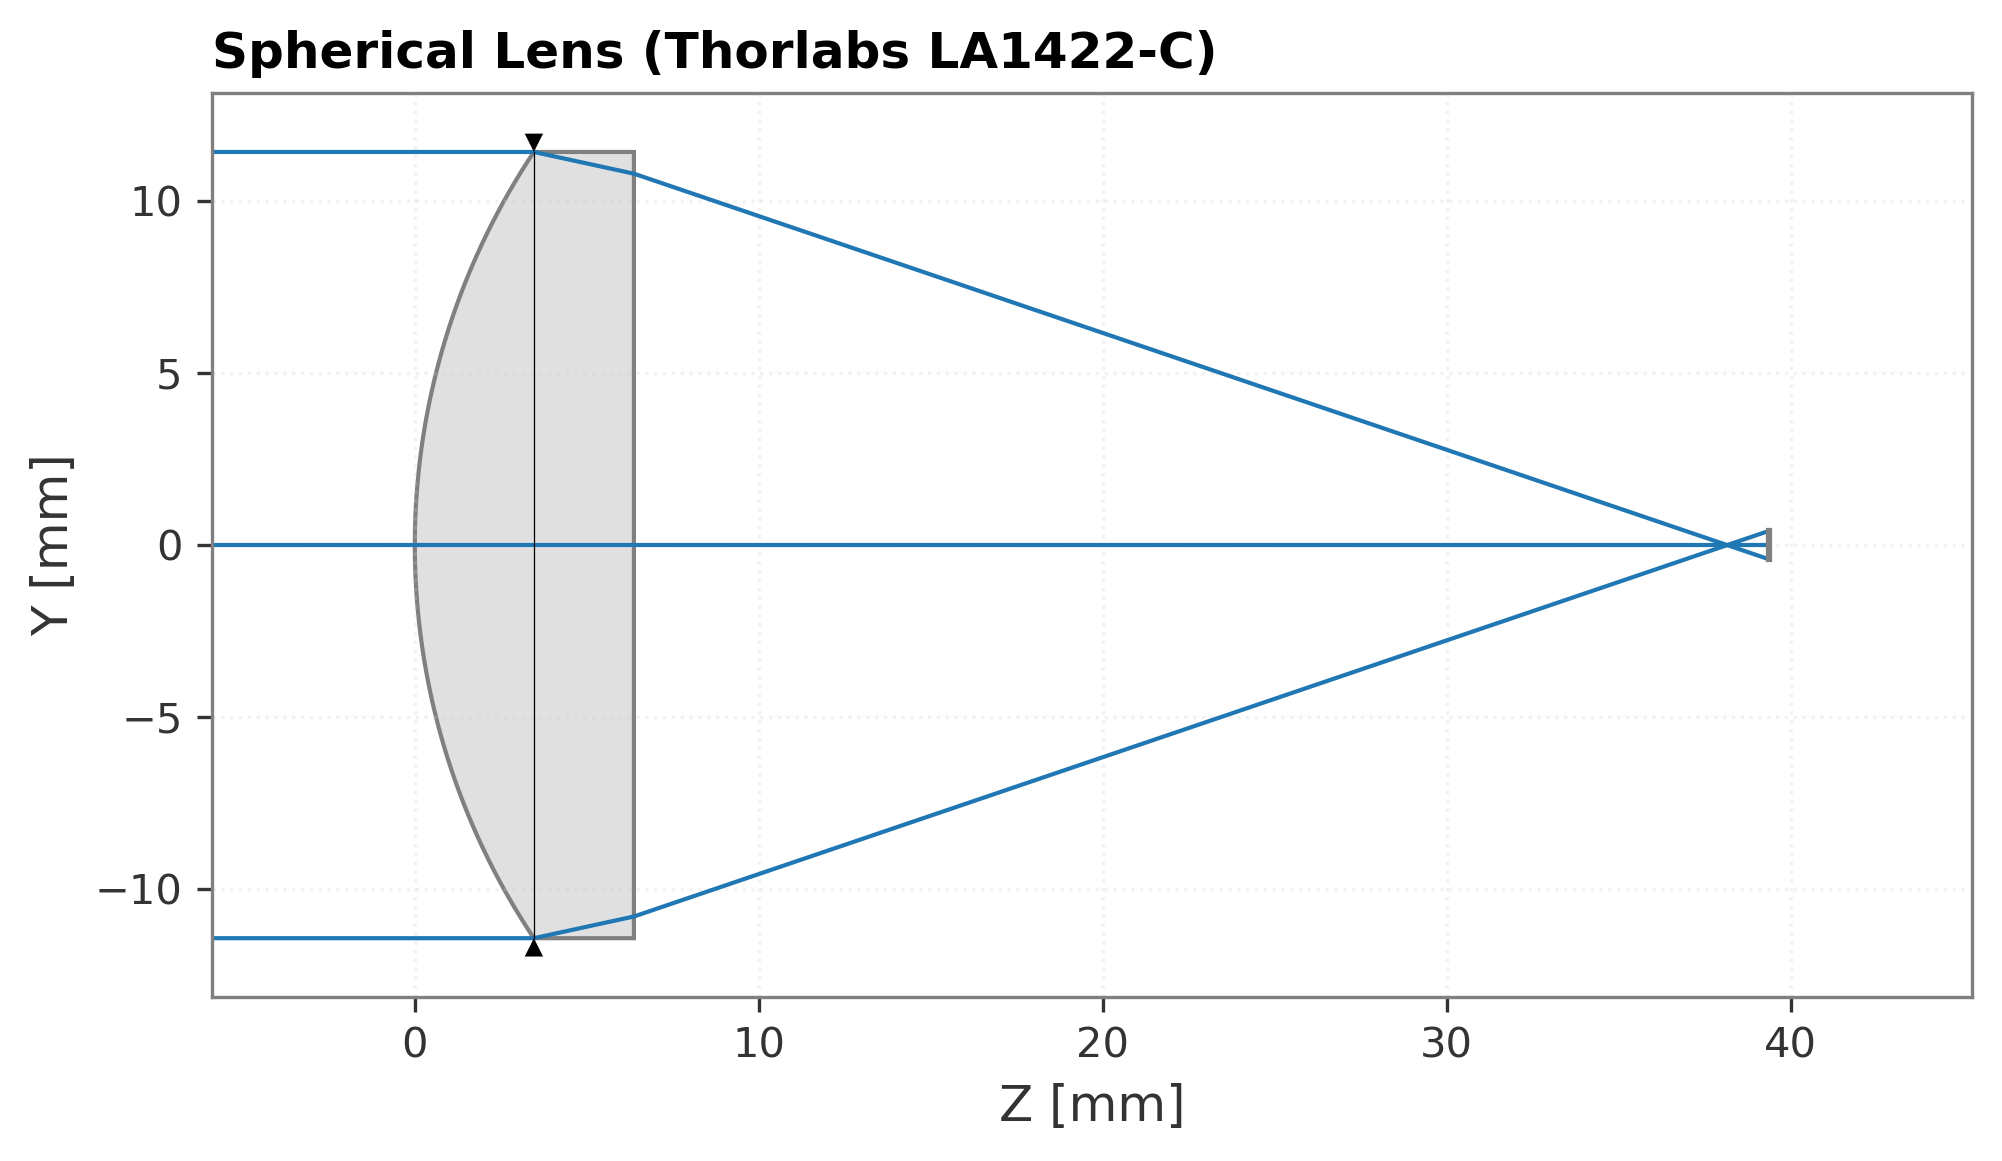

Gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Lens_Layout_Spherical.pdf
Generating aspheric lens plot...


<Figure size 3000x1200 with 0 Axes>

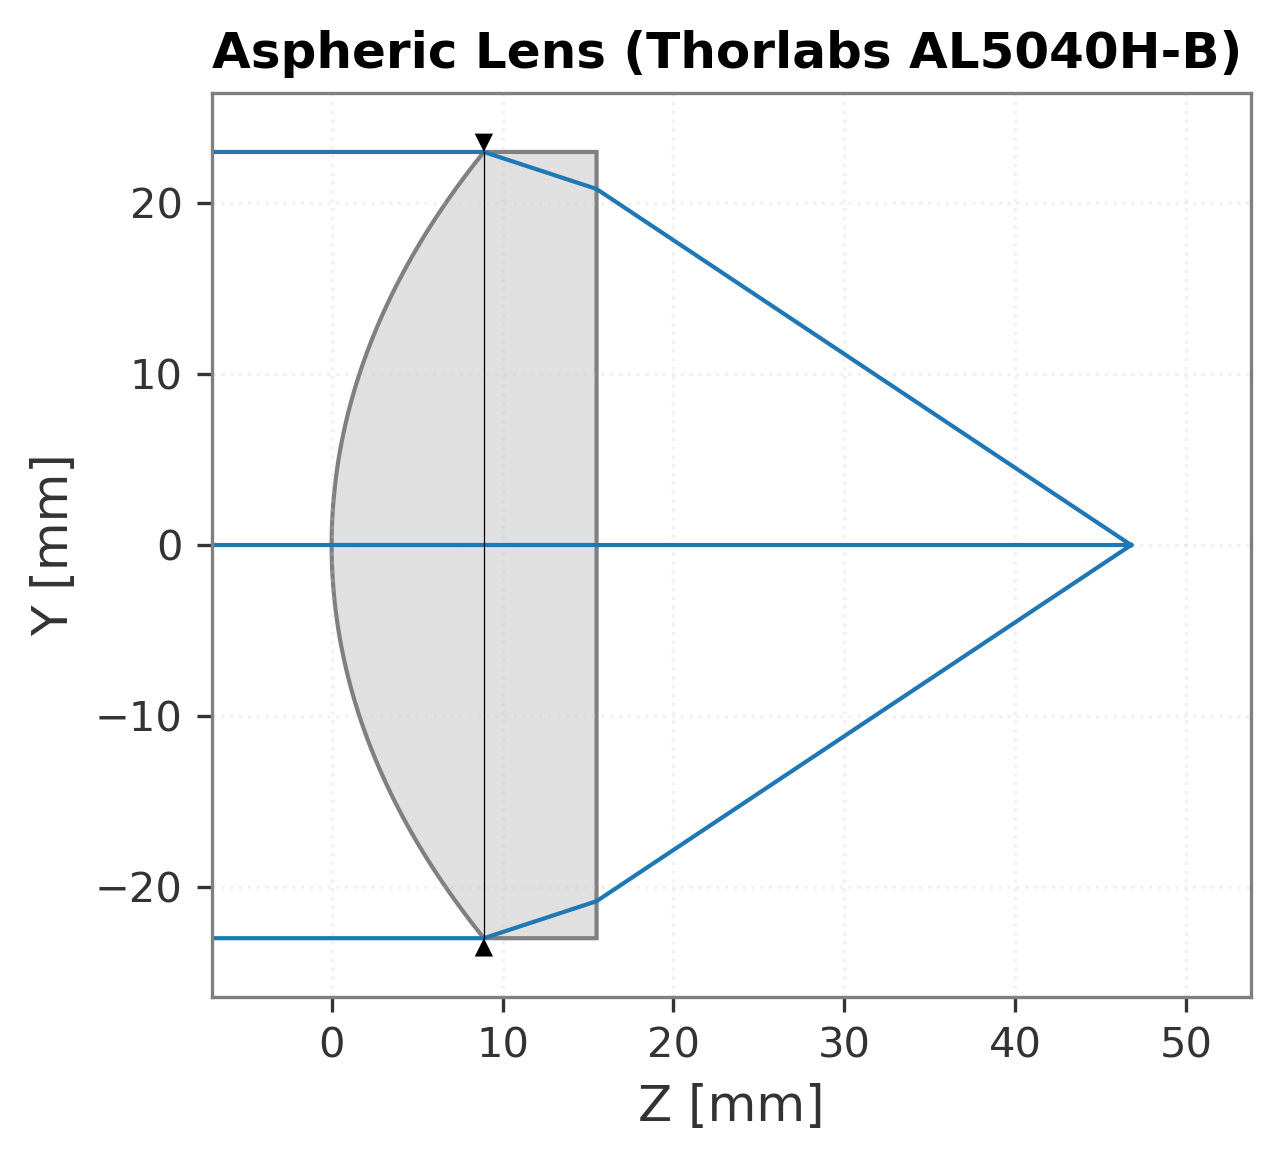

Gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Lens_Layout_Aspheric.pdf
Generating collimator plot...


<Figure size 3000x1200 with 0 Axes>

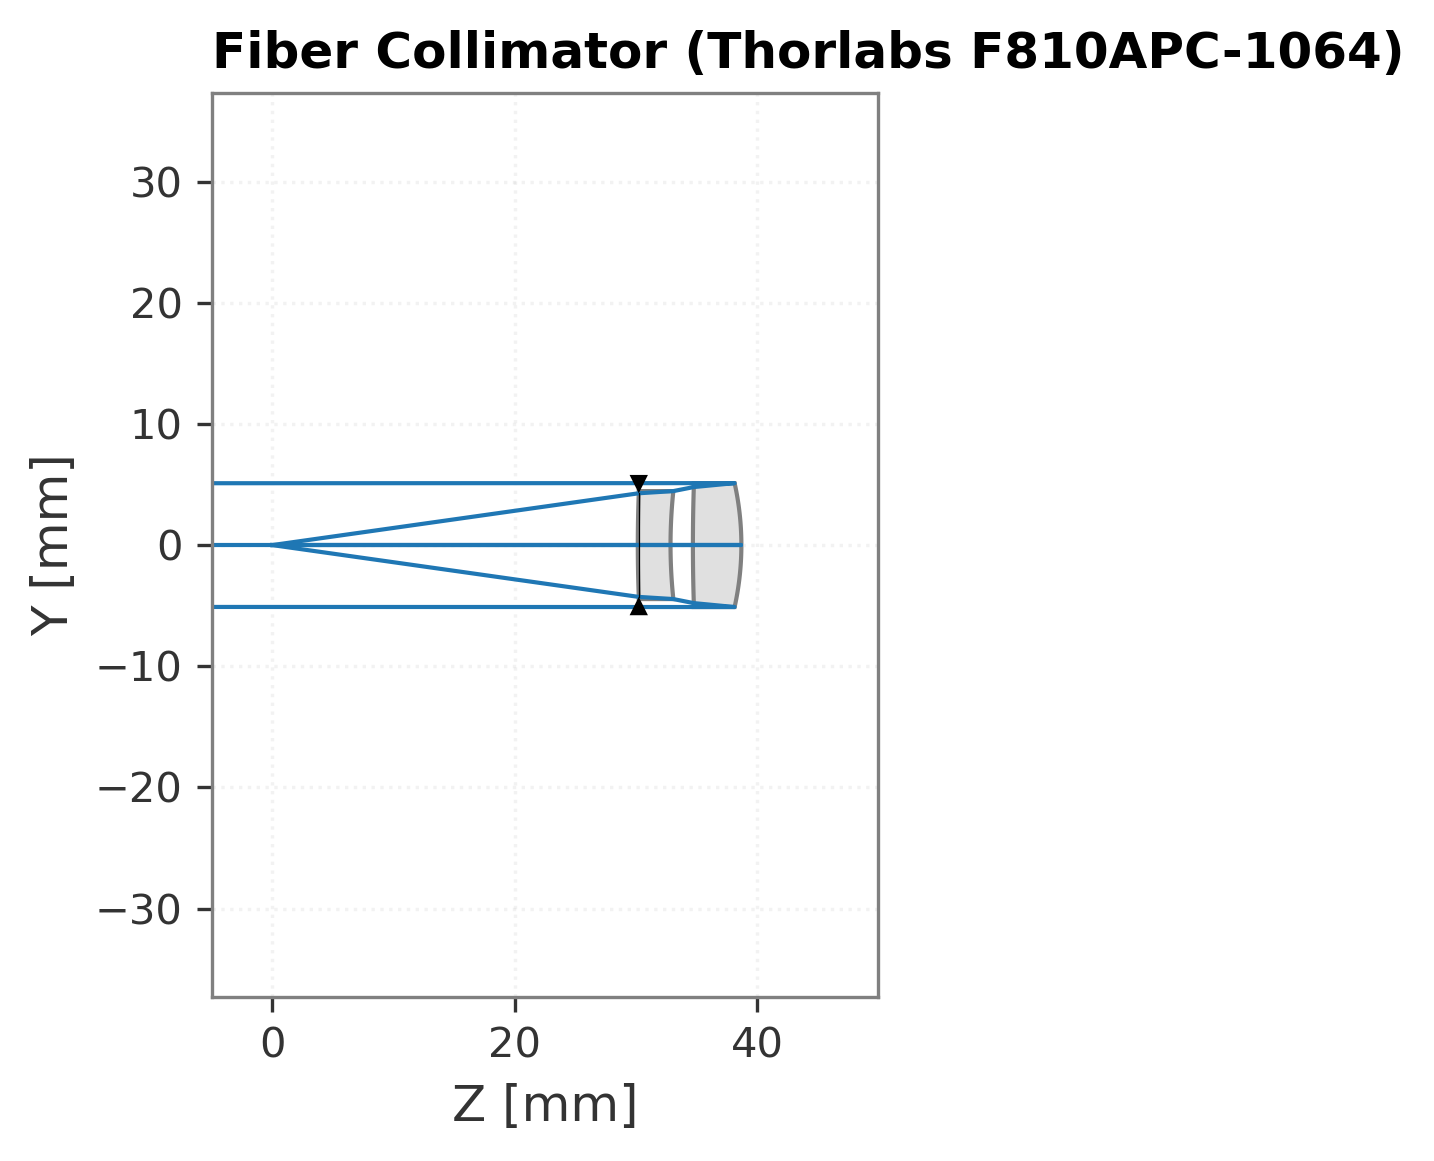

Gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Lens_Layout_Collimator.pdf
Generating combined vertical comparison plot...


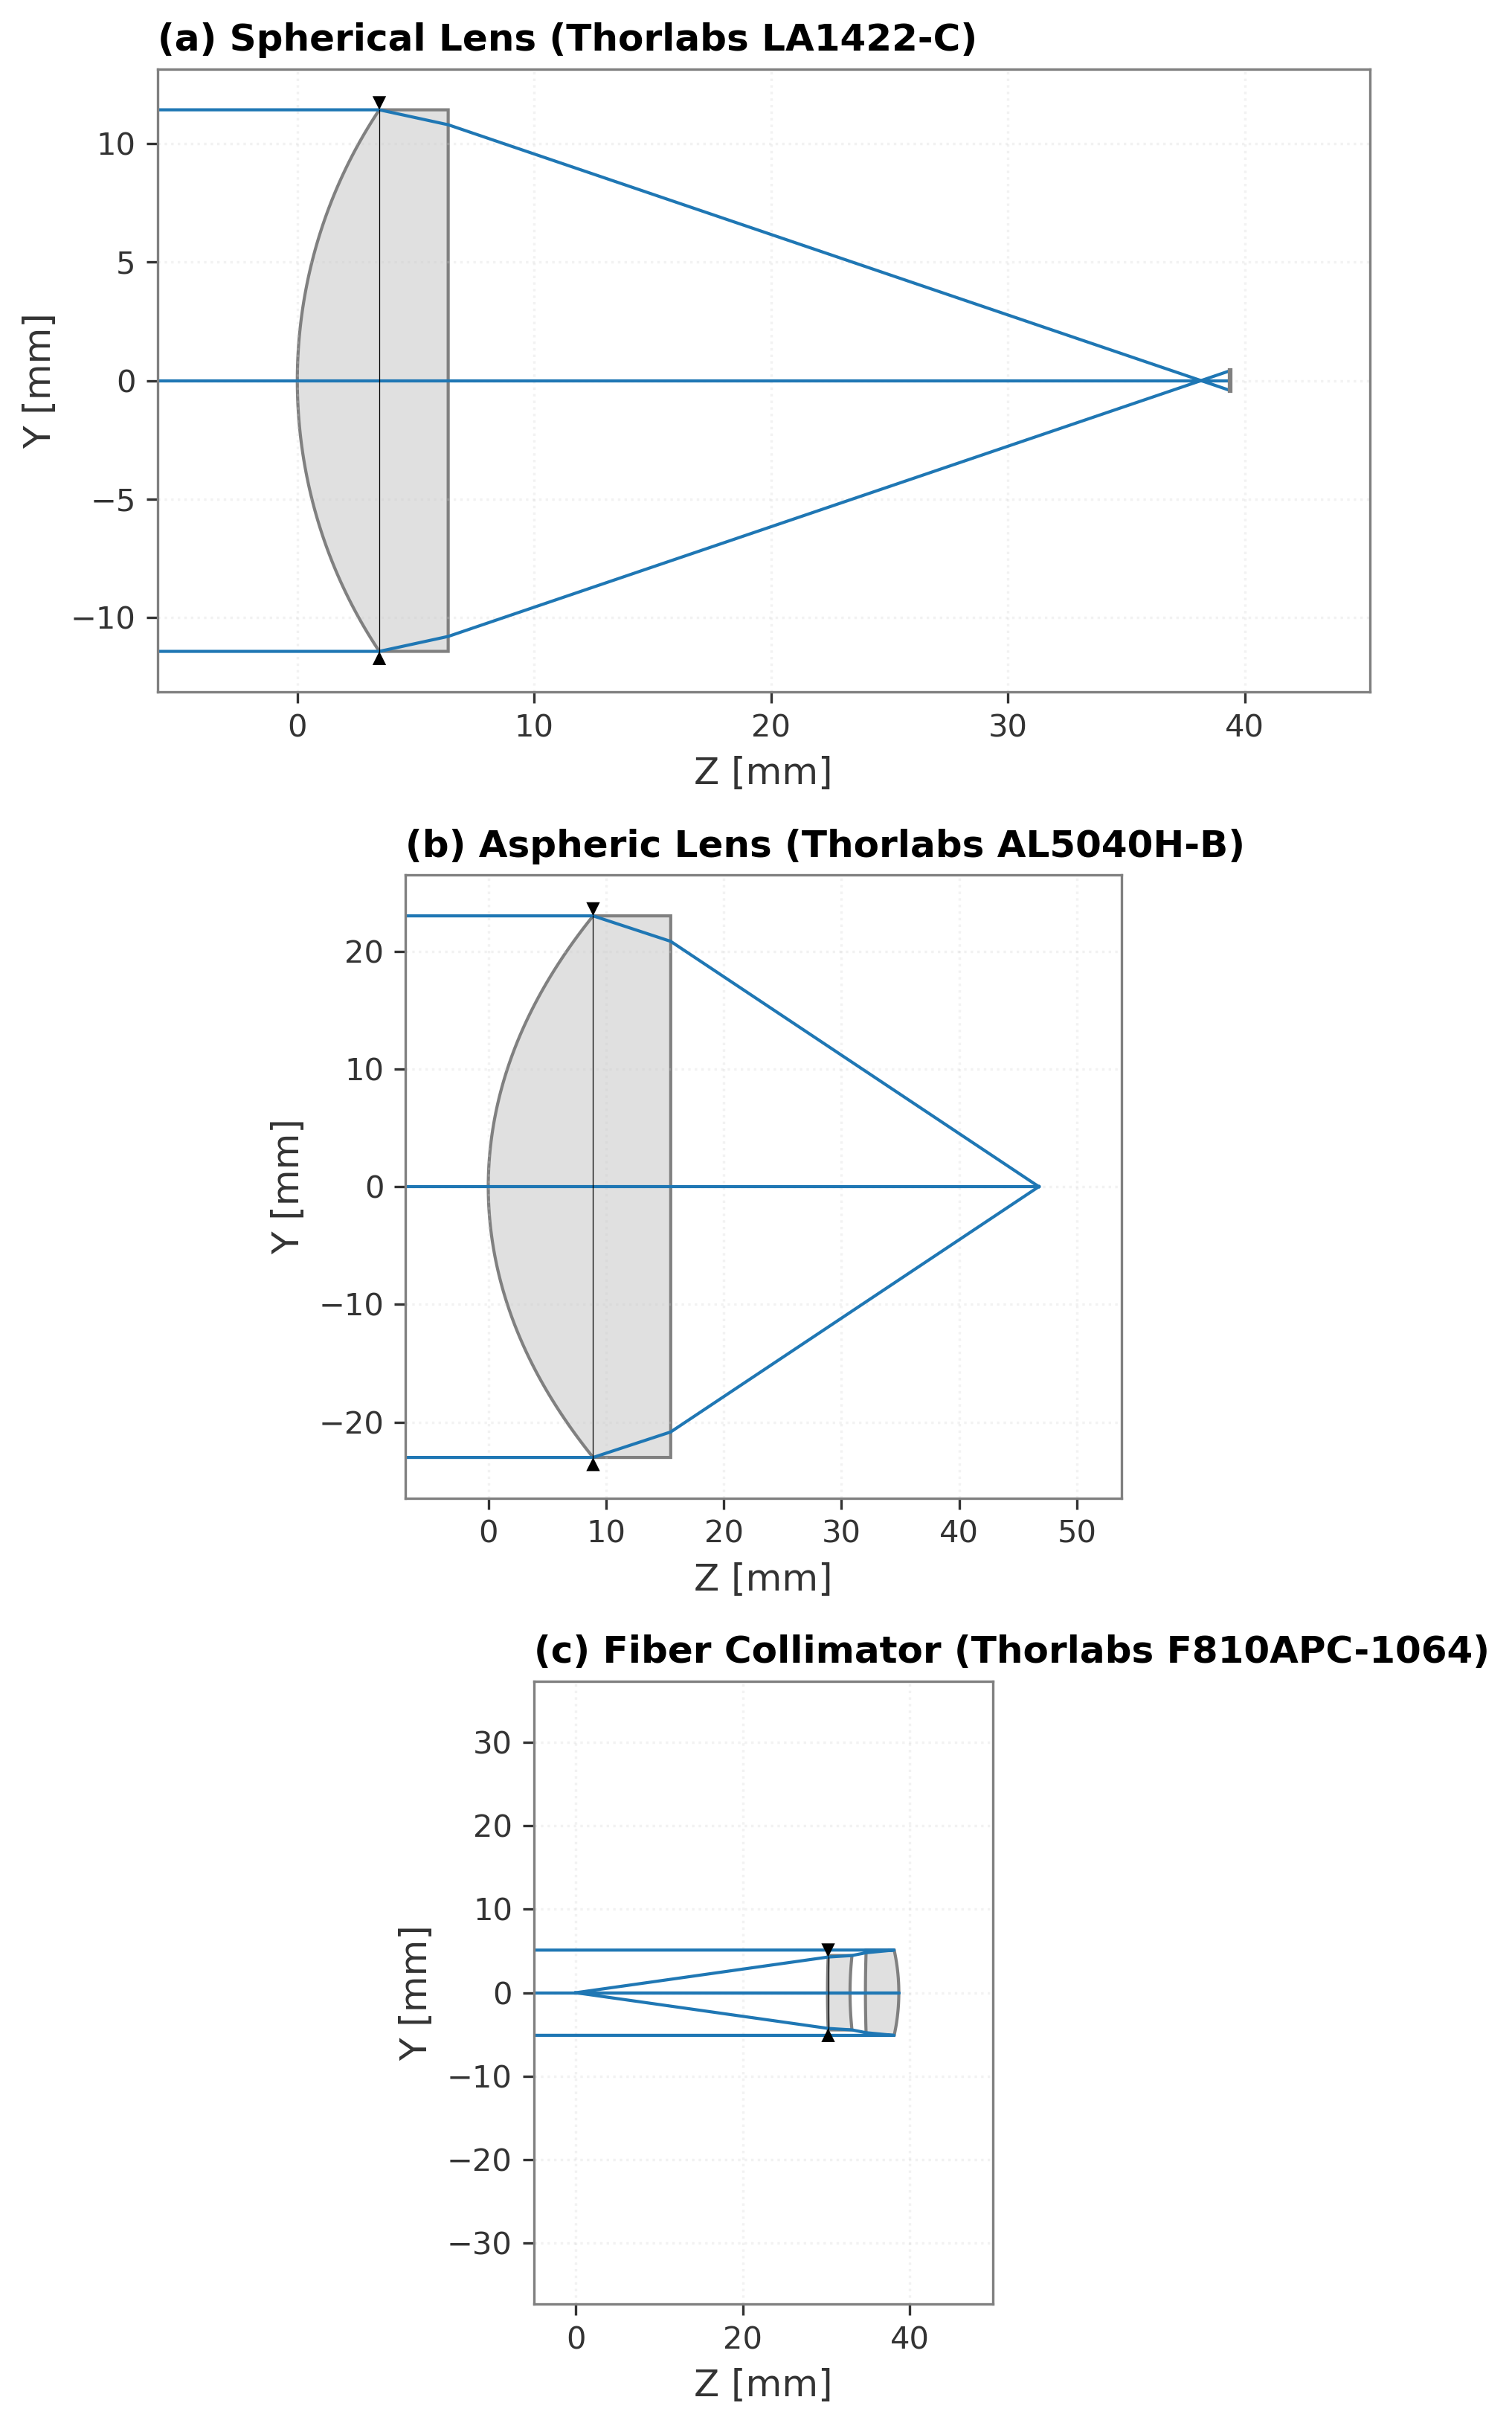

Kombinierter Plot gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Lens_Layout_Comparison_Combined.pdf


In [9]:
# === 1. Zielordner definieren ===
output_dir = r"/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses"

# Ordner automatisch erstellen, falls er nicht existiert
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# === 2. URLs der Thorlabs .zmx Dateien ===
url_sphaere = "https://media.thorlabs.com/globalassets/items/l/la/la1/la1422-c/4580-s03.zmx?v=0116120722"
url_asphaere = "https://media.thorlabs.com/globalassets/items/a/al/al5/al5040h-b/ttn122113-s03.zmx?v=0116102721"
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"

# === 3. Linsen laden ===
print("Loading lens models...")
lens_sphaere = load_zemax_file(url_sphaere)
lens_asphaere = load_zemax_file(url_asphaere)
lens_kolli = load_zemax_file(url_kolli)

# === 4. Funktion zum Generieren einzelner Plots ===
def save_lens_plot(lens_obj, title_text, filename, x_limit=None):
    plt.figure(figsize=(10, 4))
    try:
        lens_obj.draw()
        
        # Falls die Achsen durch das Assembly explodieren, manuell zoomen
        if x_limit:
            plt.xlim(x_limit)
            
    except Exception as e:
        print(f"Hinweis beim Zeichnen von {filename}: {e}")
        plt.text(0.5, 0.5, "Ray trace preview unavailable for this specific assembly structure\n(See Zemax Spot Diagrams for optical performance)", 
                 horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    
    plt.title(title_text, fontsize=12, fontweight="bold", loc="left")
    plt.xlabel("Z [mm]")
    plt.ylabel("Y [mm]")
    plt.tight_layout()
    
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath)
    plt.show()
    plt.close()
    print(f"Gespeichert unter: {filepath}")

# === 5. Einzeln ausführen und speichern ===
print("Generating spherical lens plot...")
save_lens_plot(lens_sphaere, "Spherical Lens (Thorlabs LA1422-C)", "Lens_Layout_Spherical.pdf")

print("Generating aspheric lens plot...")
save_lens_plot(lens_asphaere, "Aspheric Lens (Thorlabs AL5040H-B)", "Lens_Layout_Aspheric.pdf")

print("Generating collimator plot...")
save_lens_plot(lens_kolli, "Fiber Collimator (Thorlabs F810APC-1064)", "Lens_Layout_Collimator.pdf", x_limit=(-5, 50))


# === 6. Kombinierten Plot mit allen 3 Linsen untereinander erstellen ===
print("Generating combined vertical comparison plot...")
fig, axes = plt.subplots(3, 1, figsize=(10, 11))

# (a) Sphärische Linse
try:
    lens_sphaere.draw(ax=axes[0])
except Exception as e:
    pass
axes[0].set_title("(a) Spherical Lens (Thorlabs LA1422-C)", fontsize=12, fontweight="bold", loc="left")
axes[0].set_ylabel("Y [mm]")

# (b) Asphärische Linse
try:
    lens_asphaere.draw(ax=axes[1])
except Exception as e:
    pass
axes[1].set_title("(b) Aspheric Lens (Thorlabs AL5040H-B)", fontsize=12, fontweight="bold", loc="left")
axes[1].set_ylabel("Y [mm]")

# (c) Kollimator (mit korrigiertem Zoom)
try:
    lens_kolli.draw(ax=axes[2])
    axes[2].set_xlim(-5, 50)
except Exception as e:
    axes[2].text(0.5, 0.5, "Ray trace preview unavailable", transform=axes[2].transAxes, ha='center', va='center')
axes[2].set_title("(c) Fiber Collimator (Thorlabs F810APC-1064)", fontsize=12, fontweight="bold", loc="left")
axes[2].set_ylabel("Y [mm]")
axes[2].set_xlabel("Z [mm]")

plt.tight_layout()
combined_filepath = os.path.join(output_dir, "Lens_Layout_Comparison_Combined.pdf")
plt.savefig(combined_filepath)
plt.show()
plt.close()
print(f"Kombinierter Plot gespeichert unter: {combined_filepath}")

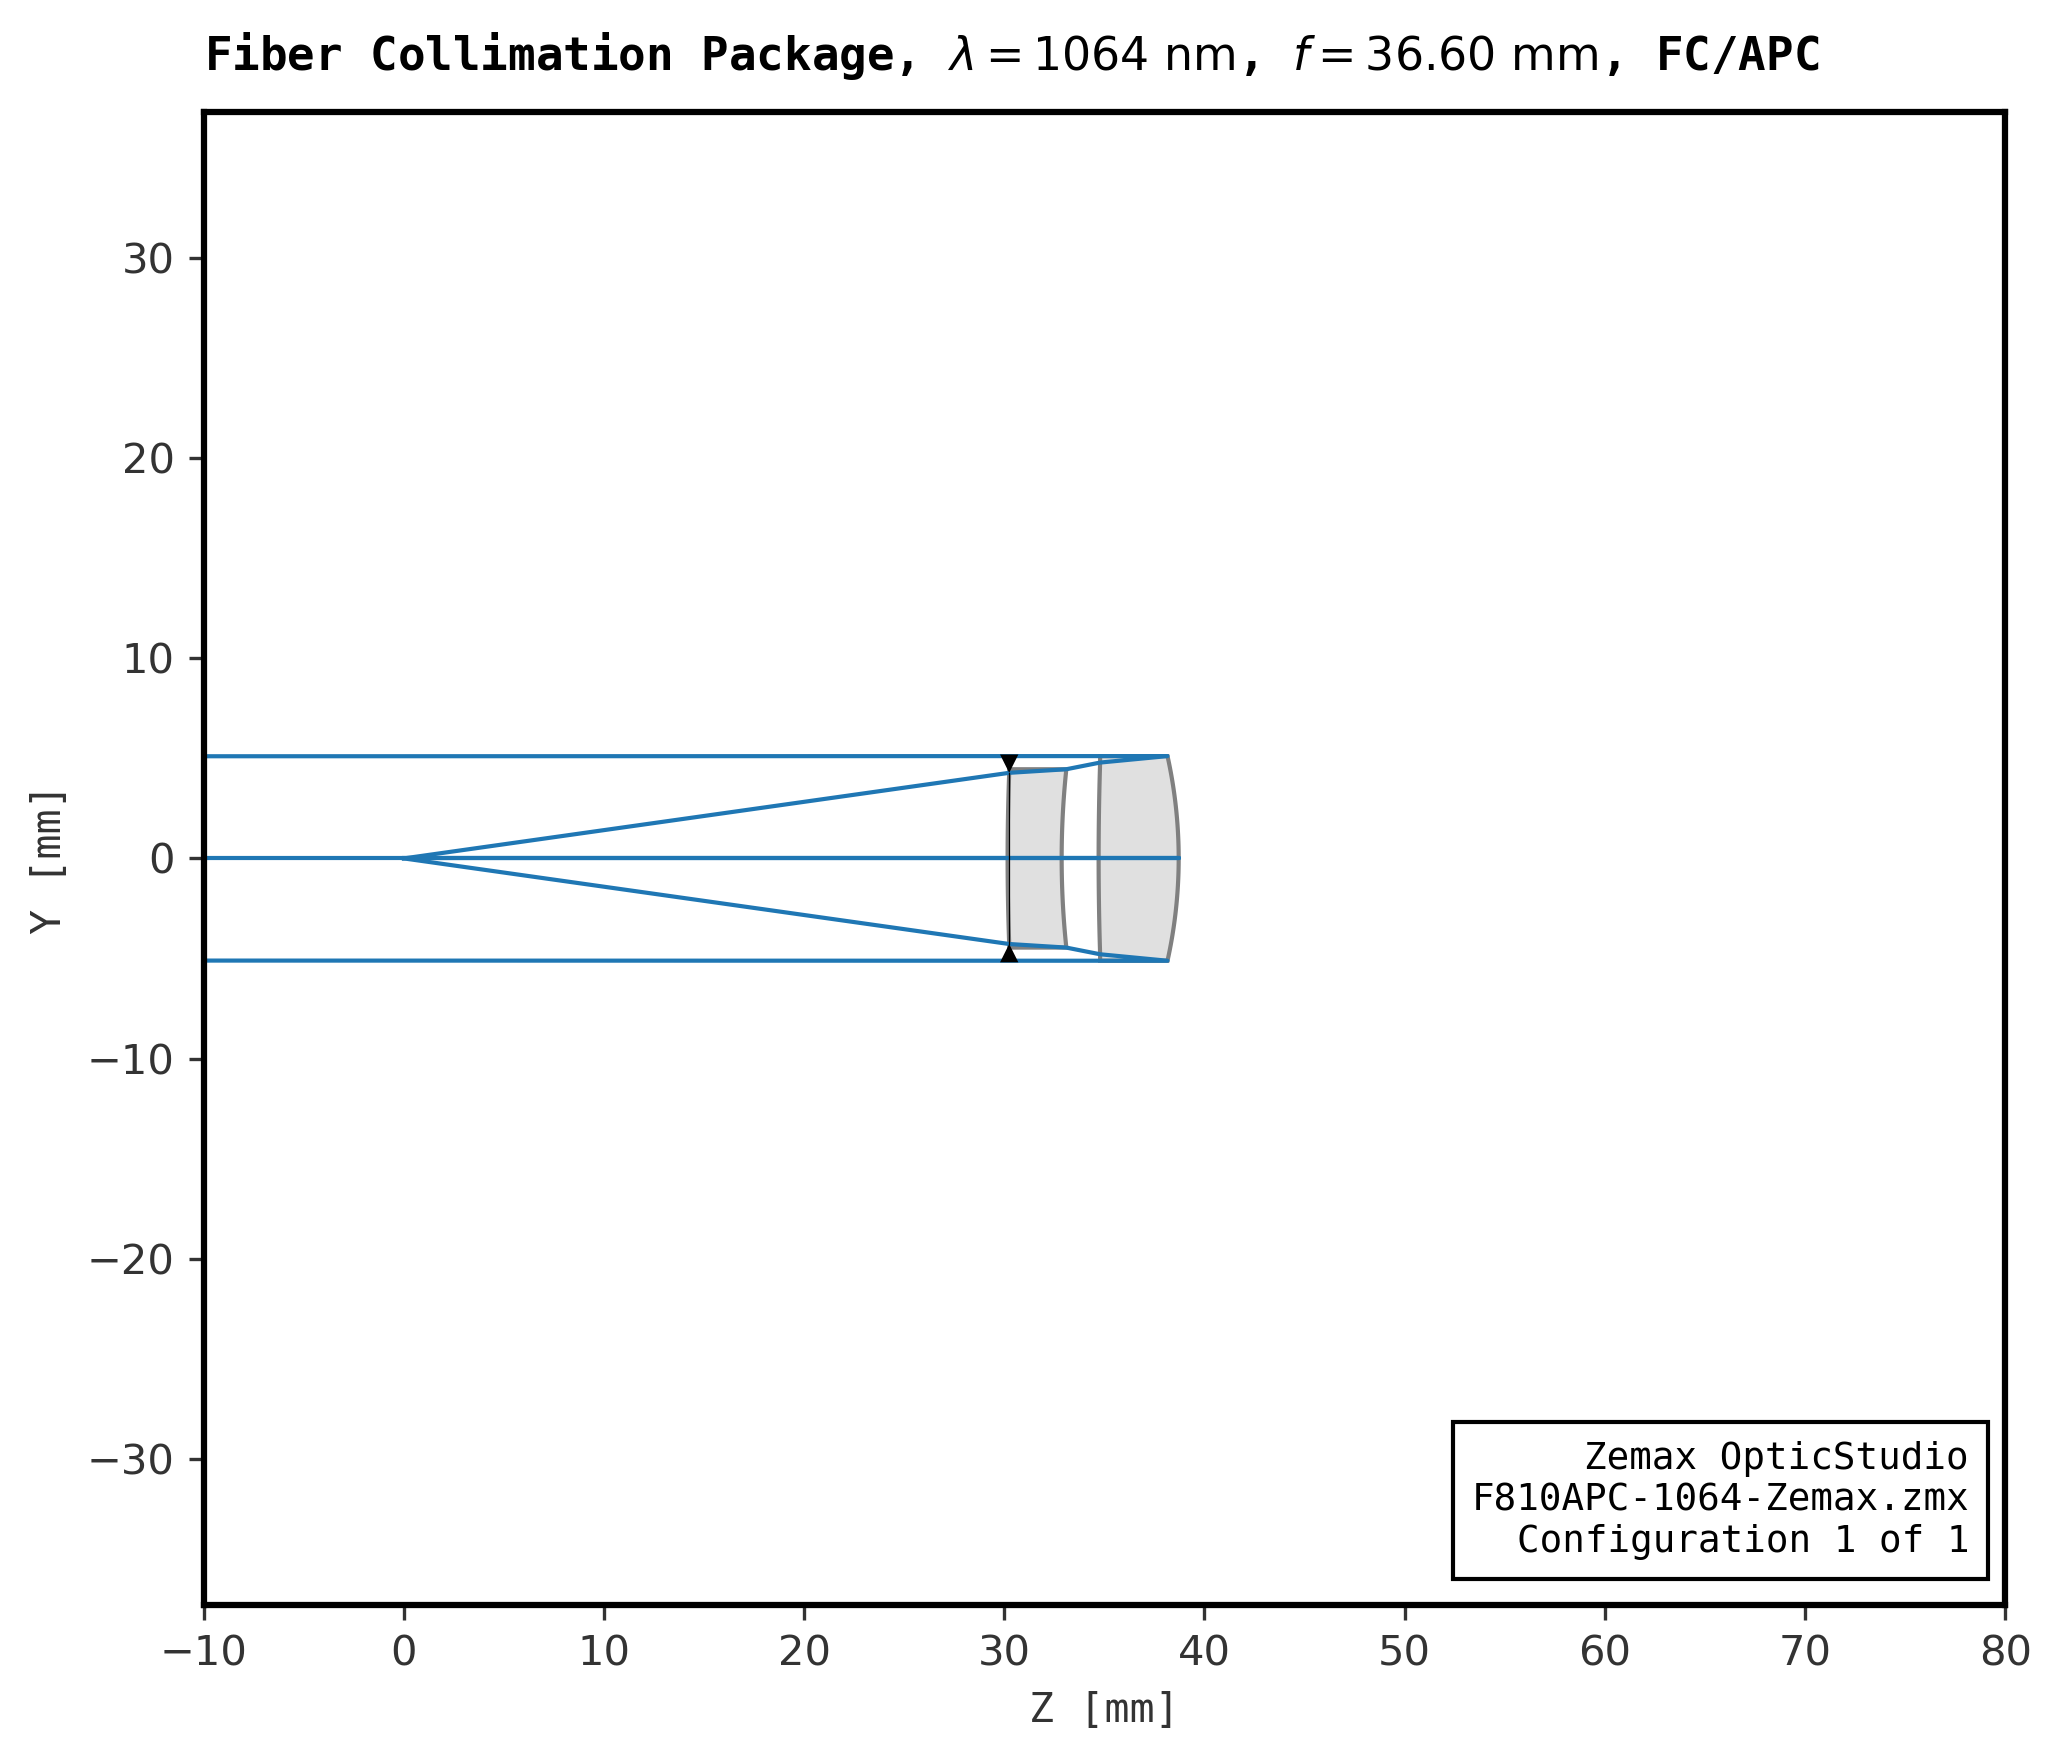

Zemax-Style Plot gespeichert unter: /Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses/Lens_Layout_Collimator_ZemaxStyle.pdf


In [10]:
# Zielordner nutzen
output_dir = r"/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/lenses"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# URL des Kollimators (falls noch nicht geladen)
url_kolli = "https://media.thorlabs.com/globalassets/items/f/f8/f81/f810apc-1064/ttn030707-s03.zmx?v=0116112438"
lens_kolli = load_zemax_file(url_kolli)

# === Zemax-Style Layout Plot erstellen ===
fig, ax = plt.subplots(figsize=(12, 6))

# Hintergrund explizit auf reinweiß setzen (ignoriert globale dark/light rcpure Einstellungen)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Optiland Ray Trace zeichnen
lens_kolli.draw(ax=ax)

# Zoom auf den relevanten Bereich des Kollimators
ax.set_xlim(-10, 80)

# Gitter ausschalten für den sauberen Blueprint-Look
ax.grid(False)

# Achsenrahmen dick und schwarz ziehen (Zemax-Rahmen)
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)

# Technische Beschriftung wie im Original-Zemax-Export
ax.set_title("Fiber Collimation Package, $\\lambda = 1064\\text{ nm}$, $f = 36.60\\text{ mm}$, FC/APC", 
             fontsize=11, loc="left", pad=10, fontweight="bold", family="monospace")
ax.set_xlabel("Z [mm]", fontsize=10, family="monospace")
ax.set_ylabel("Y [mm]", fontsize=10, family="monospace")

# Kleines "Zemax-Infobox"-Feld unten rechts ins Bild zeichnen
infobox_text = "Zemax OpticStudio\nF810APC-1064-Zemax.zmx\nConfiguration 1 of 1"
ax.text(0.98, 0.03, infobox_text, transform=ax.transAxes, 
        fontsize=9, family="monospace", verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='square,pad=0.5', facecolor='white', edgecolor='black', linewidth=1))

plt.tight_layout()

# Als PDF im gleichen Ordner speichern
filepath = os.path.join(output_dir, "Lens_Layout_Collimator_ZemaxStyle.pdf")
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
plt.close()

print(f"Zemax-Style Plot gespeichert unter: {filepath}")